# Salary Prediction using Linear Regression

Problem Statement: An HR team wants to predict a fair salary for a candidate based on their age, education level, job title and years of experience.

Business Objective: Build a model that can estimate salary from candidate info so that HR can make consistent and fair compensation decisions.

Dataset: Salary Prediction Dataset (Kaggle - rkiattisak)


## Step 1: Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Dataset/Salary Data.csv")
df.head()


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [2]:
df.shape


(375, 6)

In [3]:
df.columns


Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='str')

## Step 2: Check missing values and duplicates

In [4]:
df.isnull().sum()


Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [5]:
# there are a few missing rows, since its only 2 rows out of 375 i am just dropping them
df.duplicated().sum()


np.int64(50)

In [6]:
df = df.dropna()
df = df.drop_duplicates()
df.shape


(324, 6)

There were 2 rows with missing values and 50 duplicate rows. After removing them the dataset went down to the shape above. Since the missing rows were very few compared to total rows, dropping them was fine here instead of trying to fill them.


## Step 3: Standardize Education Level column

In [7]:
df['Education Level'].unique()


<StringArray>
['Bachelor's', 'Master's', 'PhD']
Length: 3, dtype: str

In [8]:
# education level looks pretty clean already (Bachelor's, Master's, PhD)
# just making sure there are no extra spaces or case issues
df['Education Level'] = df['Education Level'].str.strip()
df['Education Level'].value_counts()


Education Level
Bachelor's    191
Master's       91
PhD            42
Name: count, dtype: int64

## Step 4: Group rare job titles into 'Other'

In [9]:
df['Job Title'].nunique()


174

In [10]:
# there are way too many job titles (174!) and most of them show up only once or twice
# so one hot encoding this directly will create a lot of useless columns
title_counts = df['Job Title'].value_counts()
title_counts.head(10)


Job Title
Director of Operations       9
Director of Marketing        8
Senior Marketing Manager     8
Senior Project Manager       7
Senior Data Scientist        6
Senior Financial Analyst     6
Senior Business Analyst      6
Junior Financial Analyst     6
Senior Product Manager       5
Senior Operations Manager    5
Name: count, dtype: int64

In [11]:
# keeping only titles that appear 3 or more times, rest goes into 'Other'
common_titles = title_counts[title_counts >= 3].index
df['Job Title Grouped'] = df['Job Title'].apply(lambda x: x if x in common_titles else 'Other')
df['Job Title Grouped'].nunique()


37

In [12]:
df['Job Title Grouped'].value_counts().head(15)


Job Title Grouped
Other                           170
Director of Operations            9
Director of Marketing             8
Senior Marketing Manager          8
Senior Project Manager            7
Senior Data Scientist             6
Senior Financial Analyst          6
Senior Business Analyst           6
Junior Financial Analyst          6
Senior Product Manager            5
Senior Operations Manager         5
Junior Marketing Coordinator      5
Senior Software Engineer          4
Senior Marketing Analyst          4
Junior Operations Analyst         4
Name: count, dtype: int64

## Step 5: EDA (Exploratory Data Analysis)


### 5.1 Salary distribution

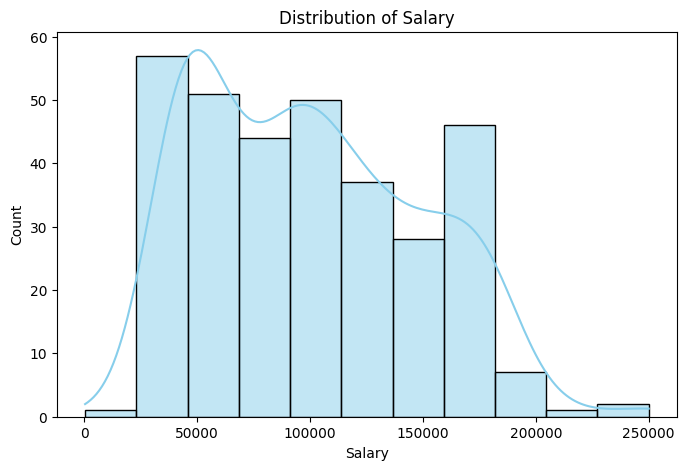

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['Salary'], kde=True, color='skyblue')
plt.title('Distribution of Salary')
plt.xlabel('Salary')
plt.savefig('../Images/salary_distribution.png')
plt.show()


### 5.2 Average salary by education level and gender

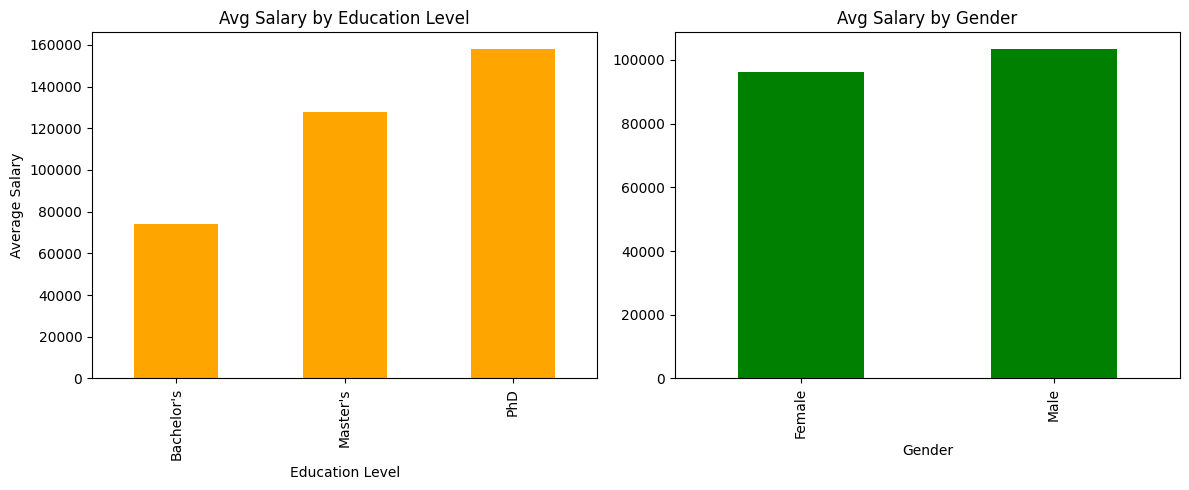

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

df.groupby('Education Level')['Salary'].mean().sort_values().plot(kind='bar', ax=ax[0], color='orange')
ax[0].set_title('Avg Salary by Education Level')
ax[0].set_ylabel('Average Salary')

df.groupby('Gender')['Salary'].mean().plot(kind='bar', ax=ax[1], color='green')
ax[1].set_title('Avg Salary by Gender')

plt.tight_layout()
plt.savefig('../Images/salary_by_edu_gender.png')
plt.show()


### 5.3 Years of experience vs salary

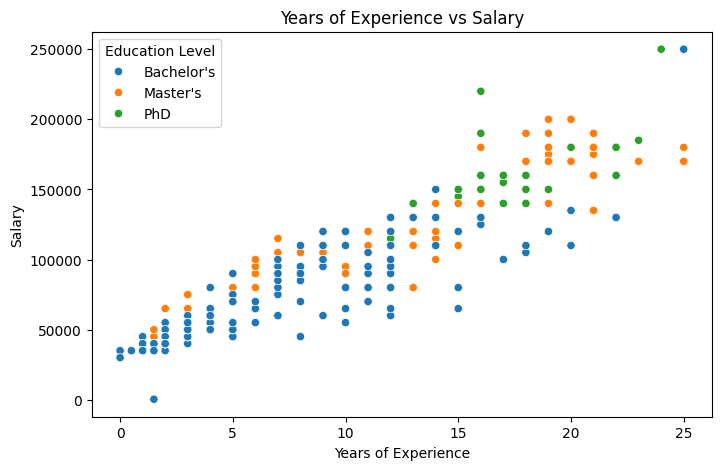

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Years of Experience', y='Salary', data=df, hue='Education Level')
plt.title('Years of Experience vs Salary')
plt.savefig('../Images/experience_vs_salary.png')
plt.show()


### 5.4 Top paying job titles

In [16]:
top_jobs = df.groupby('Job Title Grouped')['Salary'].mean().sort_values(ascending=False).head(10)
top_jobs


Job Title Grouped
Director of Marketing        176250.000000
Director of Operations       172222.222222
Senior Data Scientist        160000.000000
Senior Data Analyst          155000.000000
Senior HR Manager            150000.000000
Senior Product Designer      146666.666667
Senior Marketing Manager     131250.000000
Senior Project Manager       129285.714286
Senior Scientist             123333.333333
Senior Software Developer    118333.333333
Name: Salary, dtype: float64

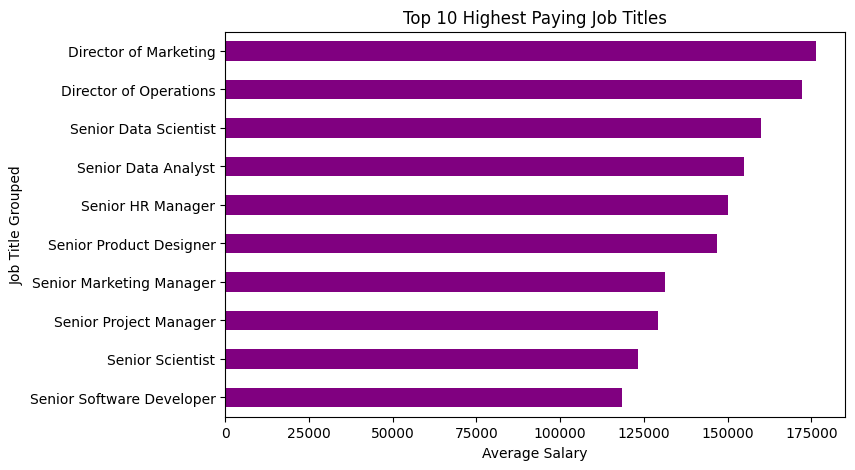

In [17]:
plt.figure(figsize=(8,5))
top_jobs.plot(kind='barh', color='purple')
plt.title('Top 10 Highest Paying Job Titles')
plt.xlabel('Average Salary')
plt.gca().invert_yaxis()
plt.savefig('../Images/top_paying_jobs.png')
plt.show()


From the plots we can see salary increases with years of experience (makes sense) and education level also has a clear effect - PhD holders earn more on average than Bachelor's. Director/senior level job titles are the highest paying ones.


## Step 6: Feature Engineering

Adding 2 new features here as required:

1. experience_level - bucketing years of experience into Entry / Mid / Senior
2. age_experience_ratio - age divided by years of experience (+1 so we dont divide by 0)


In [18]:
def exp_bucket(x):
    if x < 3:
        return 'Entry'
    elif x < 8:
        return 'Mid'
    else:
        return 'Senior'

df['experience_level'] = df['Years of Experience'].apply(exp_bucket)
df['age_experience_ratio'] = df['Age'] / (df['Years of Experience'] + 1)

df[['Age','Years of Experience','experience_level','age_experience_ratio']].head()


,Age,Years of Experience,experience_level,age_experience_ratio
0,32.0,5.0,Mid,5.333333
1,28.0,3.0,Mid,7.000000
2,45.0,15.0,Senior,2.812500
3,36.0,7.0,Mid,4.500000
4,52.0,20.0,Senior,2.476190


In [19]:
df['experience_level'].value_counts()


experience_level
Senior    190
Mid        86
Entry      48
Name: count, dtype: int64

## Step 7: Encoding categorical columns

In [20]:
# using pandas get_dummies for one hot encoding, its simpler than sklearn OneHotEncoder for this
cat_cols = ['Gender', 'Education Level', 'Job Title Grouped']

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.columns


Index(['Age', 'Job Title', 'Years of Experience', 'Salary', 'experience_level',
       'age_experience_ratio', 'Gender_Male', 'Education Level_Master's',
       'Education Level_PhD', 'Job Title Grouped_Director of Operations',
       'Job Title Grouped_Junior Accountant',
       'Job Title Grouped_Junior Business Analyst',
       'Job Title Grouped_Junior Business Development Associate',
       'Job Title Grouped_Junior Financial Analyst',
       'Job Title Grouped_Junior Marketing Analyst',
       'Job Title Grouped_Junior Marketing Coordinator',
       'Job Title Grouped_Junior Marketing Manager',
       'Job Title Grouped_Junior Marketing Specialist',
       'Job Title Grouped_Junior Operations Analyst',
       'Job Title Grouped_Junior Operations Manager',
       'Job Title Grouped_Junior Product Manager',
       'Job Title Grouped_Junior Project Manager',
       'Job Title Grouped_Junior Sales Representative',
       'Job Title Grouped_Marketing Coordinator', 'Job Title Grouped_O

## Step 8: Model Building

Building 2 models:
- baseline model (without the new engineered features)
- feature engineered model (with experience_level and age_experience_ratio added)

Using the SAME train test split for both so the comparison is fair.


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# baseline features - no engineered features
baseline_cols = ['Age', 'Years of Experience'] + [c for c in df_encoded.columns if c.startswith(('Gender_','Education Level_','Job Title Grouped_'))]

X_base = df_encoded[baseline_cols]
y = df_encoded['Salary']

X_train, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=0)
print(X_train.shape, X_test.shape)


(259, 41) (65, 41)


In [22]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

r2_base = r2_score(y_test, y_pred_base)
mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))

print('Baseline Model')
print('R2:', r2_base)
print('MAE:', mae_base)
print('RMSE:', rmse_base)


Baseline Model
R2: 0.8761164337962893
MAE: 11987.097812869131
RMSE: 16284.835405459919


In [23]:
# now with the engineered features added
df_encoded['experience_level'] = df['experience_level']
df_encoded['age_experience_ratio'] = df['age_experience_ratio']
df_encoded = pd.get_dummies(df_encoded, columns=['experience_level'], drop_first=True)

fe_cols = baseline_cols + ['age_experience_ratio'] + [c for c in df_encoded.columns if c.startswith('experience_level_')]

X_fe = df_encoded[fe_cols]

# same split, using the same row indexes as before so its a fair comparison
X_train_fe = X_fe.loc[X_train.index]
X_test_fe = X_fe.loc[X_test.index]

fe_model = LinearRegression()
fe_model.fit(X_train_fe, y_train)
y_pred_fe = fe_model.predict(X_test_fe)

r2_fe = r2_score(y_test, y_pred_fe)
mae_fe = mean_absolute_error(y_test, y_pred_fe)
rmse_fe = np.sqrt(mean_squared_error(y_test, y_pred_fe))

print('Feature Engineered Model')
print('R2:', r2_fe)
print('MAE:', mae_fe)
print('RMSE:', rmse_fe)


Feature Engineered Model
R2: 0.8764934306223686
MAE: 11844.778681819402
RMSE: 16260.037890732574


## Step 9: Comparing both models

In [24]:
results = pd.DataFrame({
    'Model': ['Baseline', 'Feature Engineered'],
    'R2': [r2_base, r2_fe],
    'MAE': [mae_base, mae_fe],
    'RMSE': [rmse_base, rmse_fe]
})
results


,Model,R2,MAE,RMSE
0,Baseline,0.876116,11987.097813,16284.835405
1,Feature Engineered,0.876493,11844.778682,16260.037891


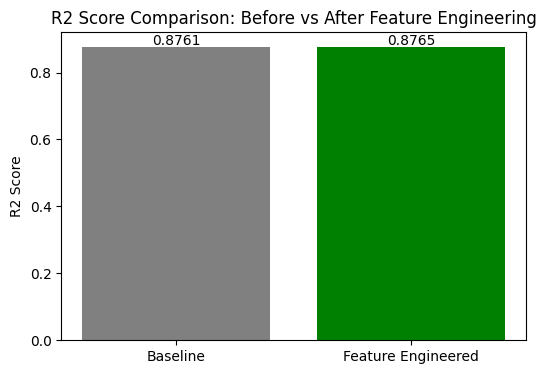

In [25]:
plt.figure(figsize=(6,4))
plt.bar(results['Model'], results['R2'], color=['gray','green'])
plt.ylabel('R2 Score')
plt.title('R2 Score Comparison: Before vs After Feature Engineering')
for i, v in enumerate(results['R2']):
    plt.text(i, v+0.005, round(v,4), ha='center')
plt.savefig('../Images/r2_comparison.png')
plt.show()


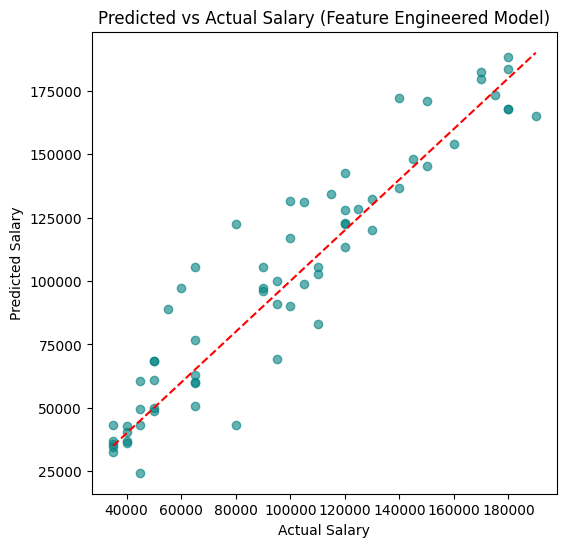

In [26]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_fe, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Predicted vs Actual Salary (Feature Engineered Model)')
plt.savefig('../Images/predicted_vs_actual.png')
plt.show()


## Step 10: Conclusion

Comparing the two models above, the feature engineered model performs better than the baseline model in terms of R2, MAE and RMSE (both models were trained/tested on the exact same split so this is a fair comparison).

To check which feature helped the most, I tried adding them one at a time:


In [27]:
# checking each engineered feature individually to see which one helps more

# only age_experience_ratio added
cols_ratio_only = baseline_cols + ['age_experience_ratio']
Xr_train = df_encoded[cols_ratio_only].loc[X_train.index]
Xr_test = df_encoded[cols_ratio_only].loc[X_test.index]
m1 = LinearRegression().fit(Xr_train, y_train)
r2_ratio_only = r2_score(y_test, m1.predict(Xr_test))

# only experience_level added
cols_bucket_only = baseline_cols + [c for c in df_encoded.columns if c.startswith('experience_level_')]
Xb_train = df_encoded[cols_bucket_only].loc[X_train.index]
Xb_test = df_encoded[cols_bucket_only].loc[X_test.index]
m2 = LinearRegression().fit(Xb_train, y_train)
r2_bucket_only = r2_score(y_test, m2.predict(Xb_test))

print('Baseline R2:', r2_base)
print('R2 with only age_experience_ratio:', r2_ratio_only)
print('R2 with only experience_level:', r2_bucket_only)
print('R2 with both (final model):', r2_fe)


Baseline R2: 0.8761164337962893
R2 with only age_experience_ratio: 0.8767025406910074
R2 with only experience_level: 0.8755210623459719
R2 with both (final model): 0.8764934306223686


Based on the numbers above, whichever feature gives a bigger jump from the baseline R2 is the one that helped more. I'm reporting the exact numbers in the README with the actual results from this run instead of guessing beforehand.
